# Clase 4 — Práctica Individual resuelta
## Joins: combinando fuentes de datos
### Maestría en Fintech · ITBA · 2026

---

Una forma de resolver los 10 ejercicios de `Clase_4_Practica_Individual.ipynb`, con la **lectura de negocio** de cada uno.

> **Hay más de un camino correcto.** Si llegaste al mismo resultado por otra vía, está bien. Y si todavía no la intentaste, hacelo primero: mirar la solución antes es como leer el final de la película.

Ejecutá **`Entorno de ejecución → Ejecutar todo`**: los datos se descargan solos del repo del curso.

---
## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)

DATOS = 'https://raw.githubusercontent.com/camilojaure/itba-pad/main/datasets/'
clientes      = pd.read_csv(DATOS + 'clientes.csv')
tarjetas      = pd.read_csv(DATOS + 'tarjetas.csv')
transacciones = pd.read_csv(DATOS + 'transacciones.csv')

transacciones['fecha'] = pd.to_datetime(transacciones['fecha'])
transacciones['mes'] = transacciones['fecha'].dt.month

print(f'clientes:      {len(clientes):>6,} filas')
print(f'tarjetas:      {len(tarjetas):>6,} filas')
print(f'transacciones: {len(transacciones):>6,} filas')

clientes:       1,000 filas
tarjetas:       2,110 filas
transacciones: 28,956 filas


---
## Ejercicio 1 · Calentamiento: ¿cuántas tarjetas tiene cada segmento?

¿Cuántas tarjetas tiene **en promedio** un cliente de cada segmento? Contá también a los que **no tienen ninguna** (para ellos, cero).

*Pista: contá tarjetas por cliente en `tarjetas`, unilo a `clientes` con `how='left'` y completá los vacíos con `fillna(0)`.*

In [2]:
# 1) Contar tarjetas por cliente  2) unir a clientes con left  3) los que no tienen, cero
tarj_cliente = tarjetas.groupby('cliente_id').size().rename('cant_tarjetas').reset_index()

t1 = clientes.merge(tarj_cliente, on='cliente_id', how='left')
t1['cant_tarjetas'] = t1['cant_tarjetas'].fillna(0)

t1.groupby('segmento')['cant_tarjetas'].mean().round(2).sort_values()

segmento
Joven      1.23
Retail     2.06
PyME       2.74
Premium    2.83
Name: cant_tarjetas, dtype: float64

In [3]:
# El error típico: hacerlo con inner (o sin fillna) deja afuera a los que no tienen tarjeta
pd.merge(clientes, tarj_cliente, on='cliente_id').groupby('segmento')['cant_tarjetas'].mean().round(2).sort_values()

segmento
Joven      1.41
Retail     2.14
PyME       2.77
Premium    2.89
Name: cant_tarjetas, dtype: float64

**Lectura esperada:** Joven **1,23** · Retail 2,06 · PyME 2,74 · Premium **2,83**. El Joven tiene casi un solo producto: es el segmento menos vinculado
y, no por casualidad, el que más se va (Clase 2). Hay espacio para venta cruzada.

Si se hace con `inner` (o sin `fillna`), los promedios suben (Joven 1,41): se pierden los 50 clientes sin tarjeta, 30 de ellos Jóvenes.
Es el Paso 4 de la guiada visto en un promedio.

---
## Ejercicio 2 · Límite de crédito por segmento

¿Cuál es el **límite de crédito mediano** de cada segmento? Solo tarjetas de **crédito** (las de débito tienen límite 0 y te arruinan la cuenta).

*Pista: `tarjetas['tipo_tarjeta'].str.contains('Crédito')` te deja solo las de crédito. Filtrá, después uní para traer el segmento.*

In [4]:
credito = tarjetas[tarjetas['tipo_tarjeta'].str.contains('Crédito')]
t2 = credito.merge(clientes[['cliente_id', 'segmento']], on='cliente_id', how='left')

limites = t2.groupby('segmento')['limite_credito'].agg(['count', 'median', 'mean']).sort_values('median')
limites

,count,median,mean
segmento,,,
Joven,86,150000.0,1.604651e+05
Retail,461,580000.0,6.204555e+05
PyME,280,2360000.0,2.544893e+06
Premium,333,5870000.0,6.267387e+06


In [5]:
print(f"Premium / Joven (mediana): {limites.loc['Premium', 'median'] / limites.loc['Joven', 'median']:.0f} veces")

Premium / Joven (mediana): 39 veces


**Lectura esperada:** Mediana: Joven **$150.000** · Retail $580.000 · PyME $2,36M · Premium **$5,87M**: unas **39 veces** más.
La mediana porque los límites son asimétricos (en todos los segmentos el promedio queda arriba de la mediana), como el balance de la Clase 2.

---
## Ejercicio 3 · ¿En qué gasta cada segmento?

Armá una tabla con el **porcentaje del gasto** de cada segmento en cada categoría: categorías en filas, segmentos en columnas,
**cada columna suma 100%**. Mostralo como heatmap.

*Pista: primero uní `transacciones` con `clientes`. Después una `pivot_table` (como en la Clase 3) y dividí cada columna por su total: `tabla / tabla.sum() * 100`.*

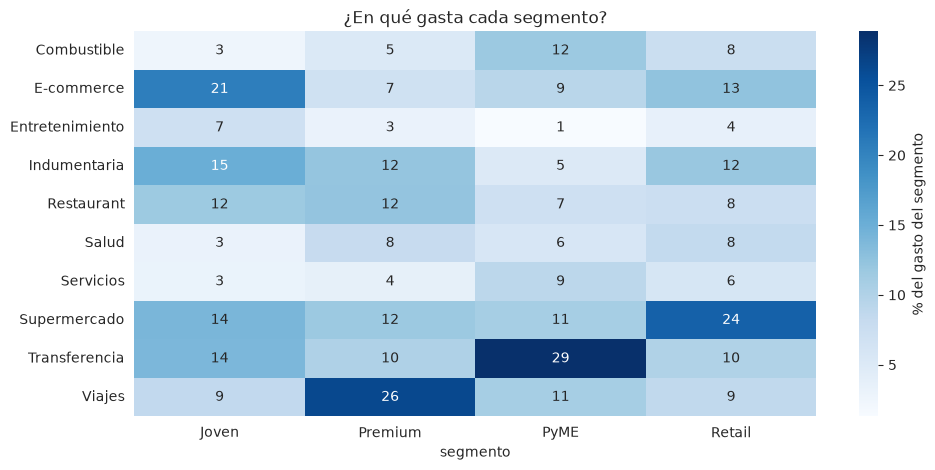

segmento
Joven         E-commerce
Premium           Viajes
PyME       Transferencia
Retail      Supermercado
dtype: object

In [6]:
df = transacciones.merge(clientes, on='cliente_id', how='left', validate='many_to_one')

mix = df.pivot_table(values='monto_ars', index='categoria', columns='segmento', aggfunc='sum')
mix = mix / mix.sum() * 100      # cada columna suma 100

sns.heatmap(mix, annot=True, fmt='.0f', cmap='Blues', cbar_kws={'label': '% del gasto del segmento'})
plt.title('¿En qué gasta cada segmento?')
plt.ylabel('')
plt.show()

mix.idxmax()

**Lectura esperada:** Cada segmento tiene su categoría: **Joven → E-commerce (21%)** · **Premium → Viajes (26%)** · **PyME → Transferencia (29%)** · **Retail → Supermercado (24%)**.
Beneficios coherentes: cuotas en e-commerce para el Joven, millas o asistencia al viajero para el Premium, transferencias sin costo para PyME,
descuentos en supermercado para Retail. Esa pregunta no se podía contestar sin un join.

---
## Ejercicio 4 · Rechazos por segmento

¿Cuál es la **tasa de rechazo** (transacciones con `aprobada == 0` sobre el total) de cada segmento?

*Pista: el truco de la Clase 2: el promedio de una columna 0/1 es una proporción. La tasa de rechazo es `1 - promedio de aprobada`.*

In [7]:
rechazo = (1 - df.groupby('segmento')['aprobada'].mean()) * 100
rechazo.round(1).sort_values(ascending=False)

segmento
Joven      9.8
Retail     5.0
PyME       4.4
Premium    2.6
Name: aprobada, dtype: float64

**Lectura esperada:** Joven **9,8%** · Retail 5,0% · PyME 4,4% · Premium **2,6%**: el Joven rechaza casi **4 veces** más.
Tiene sentido (límites chicos, poco saldo), pero cada rechazo es una mala experiencia en el segmento que más se va.
Pregunta para riesgo: ¿los rechazos son por falta de fondos, por límite o por fraude? Cada uno pide una acción distinta.

---
## Ejercicio 5 · Los que tienen tarjeta y nunca la usaron

Encontrá los clientes que **tienen al menos una tarjeta** pero **no hicieron ninguna transacción** en 2024. ¿Cuántos son, de qué segmento, y cuál es su tasa de churn?

*Pista: un left join de los clientes con tarjeta contra los clientes que operaron, con `indicator=True`. La columna `_merge` te dice
si cada fila encontró pareja (`both`) o no (`left_only`). Pedile a Gemini que te explique `indicator`.*

In [8]:
clientes_con_tarjeta = tarjetas[['cliente_id']].drop_duplicates()
clientes_que_operan  = transacciones[['cliente_id']].drop_duplicates()

t5 = clientes_con_tarjeta.merge(clientes_que_operan, on='cliente_id', how='left', indicator=True)
print(t5['_merge'].value_counts())

nunca = clientes[clientes['cliente_id'].isin(t5.loc[t5['_merge'] == 'left_only', 'cliente_id'])]
print(f"\n{len(nunca)} clientes con tarjeta que nunca operaron")
print(nunca['segmento'].value_counts())
print(f"\nChurn: {nunca['churn'].mean():.0%} (cartera: {clientes['churn'].mean():.0%})")
print(f"Balance: ${nunca['balance_ars'].sum() / 1e6:,.1f} M")

_merge
both          905
left_only      45
right_only      0
Name: count, dtype: int64

45 clientes con tarjeta que nunca operaron
segmento
Joven      25
Retail     13
PyME        4
Premium     3
Name: count, dtype: int64

Churn: 56% (cartera: 20%)
Balance: $11.6 M


In [9]:
# Extra: a nivel tarjeta, ¿cuántas tarjetas nunca se usaron?
sin_uso = ~tarjetas['tarjeta_id'].isin(transacciones['tarjeta_id'])
print(f"Tarjetas sin ninguna transacción: {sin_uso.sum()} de {len(tarjetas):,}")

Tarjetas sin ninguna transacción: 103 de 2,110


**Lectura esperada:** **45 clientes**: Joven 25, Retail 13, PyME 4, Premium 3. Churn **56%** (cartera: 20%). Balance: $11,6M.
No es un error: son clientes que aceptaron el plástico y nunca lo activaron. Campaña de **activación** (primer consumo con beneficio),
priorizando a los Premium y Retail por balance. A nivel tarjeta: **103 de 2.110 tarjetas** no tienen ni una transacción.

---
## Ejercicio 6 · Pesar la cartera: clientes vs. gasto

Para cada segmento, calculá qué **porcentaje de la cartera** representa (sobre los 1.000 clientes) y qué **porcentaje del gasto** genera.
Graficalo en barras agrupadas. Agregá el **gasto por cliente** del segmento.

*Pista: el % de la cartera sale de `clientes`; el % del gasto, de la tabla unida. Cada uno de su tabla (acordate del Paso 3).*

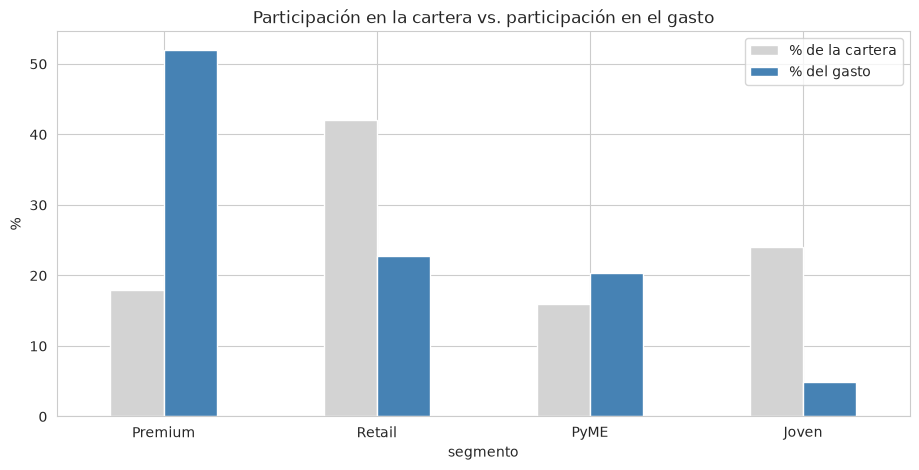

,% de la cartera,% del gasto,gasto por cliente (miles)
segmento,,,
Premium,18.0,52.0,5127.1
Retail,42.0,22.7,957.7
PyME,16.0,20.4,2261.3
Joven,24.0,4.9,362.4


In [10]:
gasto_seg = df.groupby('segmento')['monto_ars'].sum()
clientes_seg = clientes['segmento'].value_counts()

share = pd.DataFrame({
    '% de la cartera': clientes_seg / clientes_seg.sum() * 100,
    '% del gasto': gasto_seg / gasto_seg.sum() * 100,
})
share['gasto por cliente (miles)'] = gasto_seg / clientes_seg / 1e3
share = share.round(1).sort_values('% del gasto', ascending=False)

share[['% de la cartera', '% del gasto']].plot(kind='bar', color=['lightgray', 'steelblue'])
plt.title('Participación en la cartera vs. participación en el gasto')
plt.ylabel('%')
plt.xticks(rotation=0)
plt.show()

share

In [11]:
print(f"Un Premium gasta lo que {share.loc['Premium', 'gasto por cliente (miles)'] / share.loc['Joven', 'gasto por cliente (miles)']:.0f} Jóvenes")

Un Premium gasta lo que 14 Jóvenes


**Lectura esperada:** Premium: **18%** de la cartera y **52%** del gasto. Joven: **24%** y **4,9%**. Gasto por cliente: Premium ~$5,1M contra Joven ~$0,36M: **un Premium gasta lo que 14 Jóvenes**.
Es la misma conclusión de la Clase 2 (balance en riesgo) desde el gasto: retener por tasa de churn lleva al Joven; retener por valor, al Premium.

---
## Ejercicio 7 · ¿Más tarjetas, menos churn?

Usando la tabla del ejercicio 1, calculá la **tasa de churn según la cantidad de tarjetas** del cliente (0, 1, 2, 3, 4).

*Extra: repetilo **dentro de cada segmento** con una `pivot_table` (filas: cantidad de tarjetas, columnas: segmento).*

In [12]:
# Reusamos t1 (clientes + cantidad de tarjetas) del ejercicio 1
t1.groupby('cant_tarjetas')['churn'].agg(clientes='count', tasa_churn='mean').round(3)

,clientes,tasa_churn
cant_tarjetas,,
0.0,50,0.500
1.0,242,0.248
2.0,324,0.228
3.0,316,0.114
4.0,68,0.059


In [13]:
# ¿Es la tarjeta o es el segmento? Misma tabla, dentro de cada segmento
t1.pivot_table(values='churn', index='cant_tarjetas', columns='segmento', aggfunc='mean').round(2)

segmento,Joven,Premium,PyME,Retail
cant_tarjetas,,,,
0.0,0.60,0.25,0.50,0.36
1.0,0.34,0.20,0.00,0.18
2.0,0.36,0.09,0.22,0.19
3.0,NaN,0.06,0.10,0.15
4.0,NaN,0.03,0.09,NaN


**Lectura esperada:** 0 tarjetas: **50%** · 1: 25% · 2: 23% · 3: 11% · 4: **6%**. El patrón es fuerte, pero **no prueba que la tarjeta retenga**:
- Parte es segmento: los Premium tienen más tarjetas y se van menos. Dentro de cada segmento el patrón se achica, pero no desaparece (Premium 25% → 3%; Retail 36% → 15%)
- Y puede ser al revés: el cliente comprometido pide más productos, y el que se está yendo no pide nada

Para saber si dar una tarjeta retiene hace falta un experimento (ofrecerla a un grupo y no a otro), no un join.

---
## Ejercicio 8 · Tarjetas dadas de baja

Marcá a cada cliente según si tiene **al menos una tarjeta inactiva** (`activa == 0`) y compará la tasa de churn de los dos grupos.

*Pista: armá una columna `inactiva = tarjetas['activa'] == 0`, agrupá por cliente con `.max()` (¿tiene alguna?) y unilo a `clientes`.*

In [14]:
tiene_inactiva = (tarjetas.assign(inactiva=tarjetas['activa'] == 0)
                  .groupby('cliente_id')['inactiva'].max()
                  .reset_index())

t8 = clientes.merge(tiene_inactiva, on='cliente_id', how='left')
t8['inactiva'] = t8['inactiva'].eq(True)      # los que no tienen tarjeta quedan en False

t8.groupby('inactiva')['churn'].agg(clientes='count', tasa_churn='mean').round(3)

,clientes,tasa_churn
inactiva,,
False,790,0.047
True,210,0.771


In [15]:
# ¿Cuántos de los que siguen tienen una tarjeta dada de baja?
sigue = t8[(t8['churn'] == 0) & t8['inactiva']]
print(f"{len(sigue)} clientes que siguen tienen al menos una tarjeta inactiva · balance ${sigue['balance_ars'].sum() / 1e6:,.1f} M")

48 clientes que siguen tienen al menos una tarjeta inactiva · balance $48.1 M


**Lectura esperada:** Con alguna tarjeta inactiva: **77%** de churn. Sin ninguna: **4,7%**. Es la diferencia más grande del día, y por eso hay que desconfiar:
probablemente la tarjeta se da de baja **cuando** el cliente se va, no antes. Para que sirva como alerta falta la **fecha de baja de la tarjeta**
comparada con la del cliente. Si la tarjeta se apaga meses antes, es una señal excelente; si se apaga el mismo día, es la misma baja contada dos veces.
Dato útil igual: **48 clientes que siguen** tienen una tarjeta inactiva ($48,1M de balance).

---
## Ejercicio 9 · concat: apilar en vez de cruzar

Imaginá que las transacciones te llegan en **dos archivos**, uno por semestre. Simulalo: armá `s1` (meses 1 a 6) y `s2` (meses 7 a 12),
agregale a cada uno una columna `semestre` ('S1' y 'S2') y **apilalos** con `pd.concat`. Verificá que la suma de filas dé el total.

Con la tabla apilada: **¿cuántos clientes operaron en el primer semestre y no en el segundo?** ¿Qué tasa de churn tienen?

*Pista: `merge` agrega columnas; `concat` agrega filas. Para comparar semestres, contá transacciones por cliente y semestre con `groupby` + `unstack`.*

In [16]:
s1 = transacciones[transacciones['mes'] <= 6].copy()
s2 = transacciones[transacciones['mes'] >= 7].copy()
s1['semestre'] = 'S1'
s2['semestre'] = 'S2'

todo = pd.concat([s1, s2], ignore_index=True)
print(f"S1 {len(s1):,} + S2 {len(s2):,} = {len(todo):,} filas (original: {len(transacciones):,})")

S1 13,739 + S2 15,217 = 28,956 filas (original: 28,956)


In [17]:
por_semestre = todo.groupby(['cliente_id', 'semestre']).size().unstack(fill_value=0)
solo_s1 = por_semestre[(por_semestre['S1'] > 0) & (por_semestre['S2'] == 0)]
print(f"Operaron en S1 y no en S2: {len(solo_s1)} clientes")

perfil = clientes[clientes['cliente_id'].isin(solo_s1.index)]
print(f"Churn de esos clientes: {perfil['churn'].mean():.0%}")
print(perfil['segmento'].value_counts())

Operaron en S1 y no en S2: 68 clientes
Churn de esos clientes: 100%
segmento
Joven      29
Retail     29
PyME        9
Premium     1
Name: count, dtype: int64


**Lectura esperada:** 13.739 + 15.217 = **28.956** filas. **68 clientes** operaron en S1 y no en S2, y **el 100% se fue** (Joven 29, Retail 29, PyME 9, Premium 1).
Es el Paso 7 de la guiada con otra herramienta: dejar de operar un semestre es churn casi seguro.
Usos de `concat`: juntar los exports mensuales de un sistema, o el mismo reporte de varias sucursales. El requisito es que las columnas se llamen igual.

---
## Ejercicio 10 · Desafío: la vista 360 para el comité

El comité de retención te pide **una tabla con una fila por cliente** y una lista de a quién llamar.

1. Armá la vista: `segmento`, `balance_ars`, `churn`, **cantidad de tarjetas**, **tarjetas inactivas**, **monto 2024**, **cantidad de transacciones** y **último mes con operaciones**. Tiene que tener **1.000 filas** y el balance total tiene que dar **$693M**
2. Entre los clientes que **siguen** (`churn == 0`), marcá dos señales: **no operó en diciembre** (incluye a los que nunca operaron) y **tiene alguna tarjeta inactiva**
3. ¿Cuántos tienen **al menos una señal**? ¿Cuánto balance suman? ¿De qué segmento son?

*Pistas: es el Paso 5 de la guiada con dos columnas más. **Primero resumís cada tabla por cliente, después unís.** Si el balance no da $693M, algo se multiplicó.*

In [18]:
# 1) Resumir cada tabla por cliente
gasto_cliente = transacciones.groupby('cliente_id').agg(
    monto_2024=('monto_ars', 'sum'),
    cant_transacciones=('transaccion_id', 'count'),
    ultimo_mes=('mes', 'max'),
).reset_index()

tarj = (tarjetas.assign(inactiva=tarjetas['activa'] == 0)
        .groupby('cliente_id')
        .agg(cant_tarjetas=('tarjeta_id', 'count'), tarjetas_inactivas=('inactiva', 'sum'))
        .reset_index())

# 2) Unir contra clientes, con left
vista = (clientes[['cliente_id', 'nombre', 'segmento', 'provincia', 'balance_ars', 'churn']]
         .merge(tarj, on='cliente_id', how='left')
         .merge(gasto_cliente, on='cliente_id', how='left'))
cols = ['cant_tarjetas', 'tarjetas_inactivas', 'monto_2024', 'cant_transacciones']
vista[cols] = vista[cols].fillna(0)

print(f"{len(vista):,} filas (una por cliente) · balance ${vista['balance_ars'].sum() / 1e6:,.0f} M")
vista.head()

1,000 filas (una por cliente) · balance $693 M


,cliente_id,nombre,segmento,provincia,balance_ars,churn,cant_tarjetas,tarjetas_inactivas,monto_2024,cant_transacciones,ultimo_mes
0,C0001,Guadalupe Luna,Premium,Buenos Aires,2055200.0,0,4.0,0.0,6106148.05,41.0,12.0
1,C0002,Lucas Moreno,Joven,Buenos Aires,20300.0,1,1.0,1.0,97915.77,5.0,7.0
2,C0003,Matías Peralta,Retail,Córdoba,55100.0,1,3.0,3.0,451967.63,11.0,9.0
3,C0004,Isabella Ledesma,Retail,CABA,115200.0,0,2.0,0.0,1674276.32,50.0,12.0
4,C0005,Diego Rojas,Joven,Entre Ríos,32100.0,1,1.0,1.0,0.00,0.0,NaN


In [19]:
# 3) Señales, solo entre los que siguen
siguen = vista[vista['churn'] == 0].copy()
siguen['no_opero_en_dic'] = ~(siguen['ultimo_mes'] == 12)      # incluye a los que nunca operaron
siguen['tarjeta_inactiva'] = siguen['tarjetas_inactivas'] > 0
siguen['en_riesgo'] = siguen['no_opero_en_dic'] | siguen['tarjeta_inactiva']

riesgo = siguen[siguen['en_riesgo']]
print(f"Clientes que siguen: {len(siguen)}")
print(f"  · no operaron en diciembre: {siguen['no_opero_en_dic'].sum()}")
print(f"  · con tarjeta inactiva:     {siguen['tarjeta_inactiva'].sum()}")
print(f"  · con al menos una señal:   {len(riesgo)} · balance ${riesgo['balance_ars'].sum() / 1e6:,.1f} M "
      f"({riesgo['balance_ars'].sum() / siguen['balance_ars'].sum():.0%} del balance de los que siguen)")
print()
print(riesgo.groupby('segmento').agg(clientes=('cliente_id', 'count'), balance_M=('balance_ars', 'sum'))
      .assign(balance_M=lambda d: (d['balance_M'] / 1e6).round(1))
      .sort_values('balance_M', ascending=False))

Clientes que siguen: 801
  · no operaron en diciembre: 74
  · con tarjeta inactiva:     48
  · con al menos una señal:   120 · balance $74.4 M (12% del balance de los que siguen)

          clientes  balance_M
segmento                     
Premium         27       49.0
Retail          48       14.7
PyME            10        8.9
Joven           35        1.8


In [20]:
riesgo.sort_values('balance_ars', ascending=False)[
    ['cliente_id', 'nombre', 'segmento', 'balance_ars', 'ultimo_mes', 'tarjetas_inactivas']].head(10)

,cliente_id,nombre,segmento,balance_ars,ultimo_mes,tarjetas_inactivas
732,C0733,Catalina Acosta,Premium,5118300.0,12.0,1.0
907,C0908,Malena Medina,Premium,4084600.0,12.0,1.0
654,C0655,Santiago Ramírez,Premium,3695900.0,12.0,1.0
463,C0464,Lucía Sosa,Premium,3579900.0,NaN,0.0
360,C0361,Malena Ramírez,Premium,3439200.0,12.0,1.0
142,C0143,Pilar Juárez,Premium,3403400.0,12.0,1.0
885,C0886,Nicolás Álvarez,Premium,2699000.0,NaN,0.0
480,C0481,Pilar Villalba,PyME,2211900.0,12.0,1.0
933,C0934,Mía González,Premium,2152400.0,11.0,0.0
567,C0568,Ignacio Torres,Premium,2143900.0,12.0,2.0


**Lectura esperada:** Vista: 1.000 filas, $693M. De los **801** que siguen: **74** no operaron en diciembre (29 que dejaron de operar + 45 que nunca operaron) y **48** tienen una tarjeta inactiva.
Con al menos una señal: **120 clientes** con **$74,4M** de balance (**12%** del balance de los que siguen).

Por segmento: **Premium 27 clientes y $49,0M** · Retail 48 y $14,7M · PyME 10 y $8,9M · Joven 35 y $1,8M.

Bullets modelo:
1. 120 clientes que siguen con nosotros muestran señales de salida; tienen $74,4M, el 12% del balance vigente
2. Dos tercios de esa plata son **27 Premium**. Los Jóvenes son 35, pero suman $1,8M
3. Llamar primero a los Premium con tarjeta inactiva o sin operar en diciembre, y dejar armada esta consulta como alerta mensual